<a href="https://colab.research.google.com/github/AxdKyn13/Projects-Trial/blob/main/trial_psl_uts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FFT

Mounted at /content/drive
Kolom yang tersedia: Index(['1500966308.00'], dtype='object')


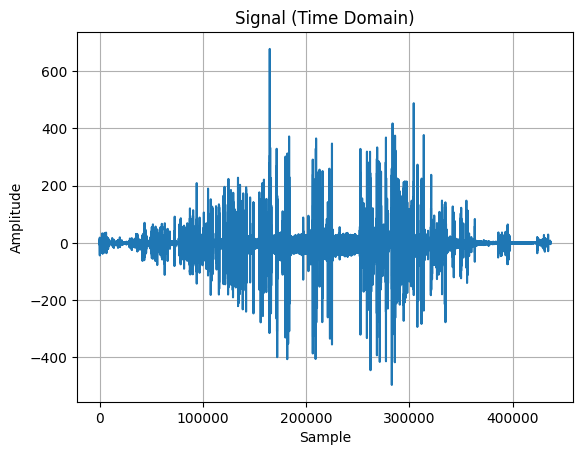

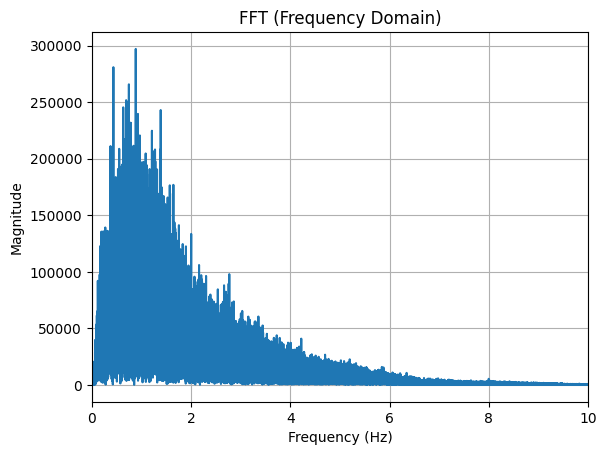

In [ ]:
# =========================
# IMPORT LIBRARY
# =========================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import drive

# =========================
# LOAD DATA
# =========================
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Pengolahan Sinyal Lanjut (Final Project)/trial/BVP.csv'  # <<< GANTI sesuai lokasi file kamu
data = pd.read_csv(file_path)

print("Kolom yang tersedia:", data.columns)

# Ambil kolom pertama (aman untuk awal)
signal = data.iloc[:, 0].values

# =========================
# PARAMETER
# =========================
fs = 64  # <<< GANTI sesuai sampling rate kamu

# =========================
# PREPROCESSING
# =========================
signal = signal - np.mean(signal)  # hilangkan DC offset

N = len(signal)

# windowing
window = np.hamming(N)
signal = signal * window

# =========================
# FFT
# =========================
fft_vals = np.fft.fft(signal)
fft_vals = np.abs(fft_vals[:N//2])

freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

# =========================
# PLOT TIME DOMAIN
# =========================
plt.figure()
plt.plot(signal)
plt.title("Signal (Time Domain)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid()

# =========================
# PLOT FFT
# =========================
plt.figure()
plt.plot(freqs, fft_vals)
plt.title("FFT (Frequency Domain)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, 10)
plt.grid()

plt.show()

FIR filter

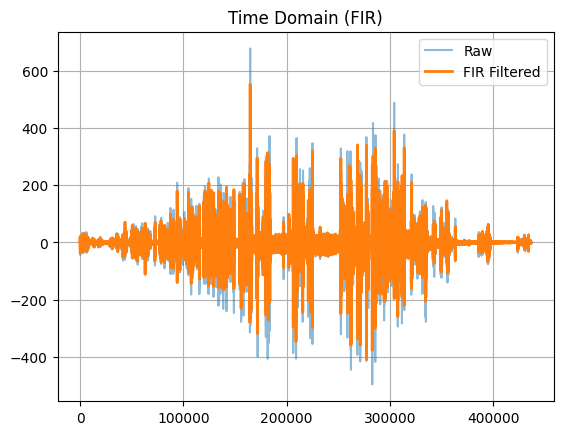

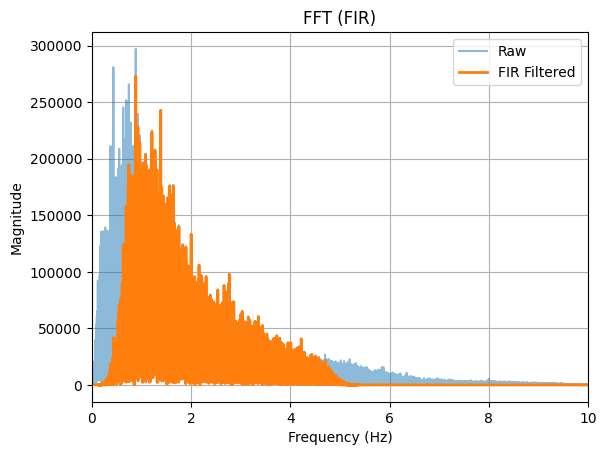

In [ ]:
# =========================
# IMPORT TAMBAHAN
# =========================
from scipy.signal import firwin, filtfilt

# =========================
# PARAMETER FIR
# =========================
lowcut = 0.5
highcut = 5
numtaps = 201  # jumlah koefisien (semakin besar → semakin tajam)

nyquist = 0.5 * fs

# =========================
# DESIGN FIR FILTER
# =========================
fir_coeff = firwin(numtaps, [lowcut/nyquist, highcut/nyquist], pass_zero=False)

# =========================
# APPLY FILTER
# =========================
filtered_signal_fir = filtfilt(fir_coeff, [1.0], signal)

# =========================
# FFT
# =========================
N = len(signal)
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

fft_raw = np.abs(np.fft.fft(signal)[:N//2])
fft_fir = np.abs(np.fft.fft(filtered_signal_fir)[:N//2])

# =========================
# PLOT TIME DOMAIN
# =========================
plt.figure()
plt.plot(signal, label='Raw', alpha=0.5)
plt.plot(filtered_signal_fir, label='FIR Filtered', linewidth=2)
plt.title("Time Domain (FIR)")
plt.legend()
plt.grid()

# =========================
# PLOT FFT
# =========================
plt.figure()
plt.plot(freqs, fft_raw, label='Raw', alpha=0.5)
plt.plot(freqs, fft_fir, label='FIR Filtered', linewidth=2)
plt.xlim(0, 10)
plt.title("FFT (FIR)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()

plt.show()

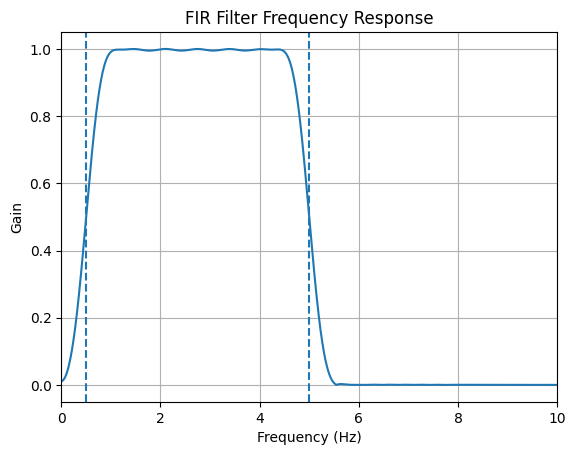

In [ ]:
from scipy.signal import freqz

# =========================
# FREQUENCY RESPONSE
# =========================
w, h = freqz(fir_coeff, worN=8000)

# ubah ke Hz
freq = (w / np.pi) * (fs / 2)

# magnitude
magnitude = np.abs(h)

# =========================
# PLOT
# =========================
plt.figure()
plt.plot(freq, magnitude)
plt.title("FIR Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")
plt.grid()

# highlight range penting
plt.axvline(0.5, linestyle='--')
plt.axvline(5, linestyle='--')

plt.xlim(0, 10)
plt.show()

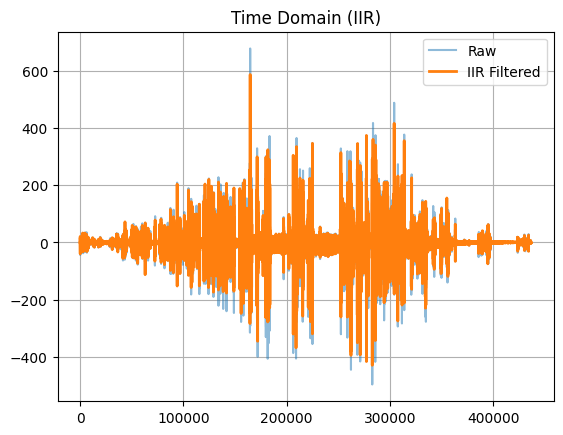

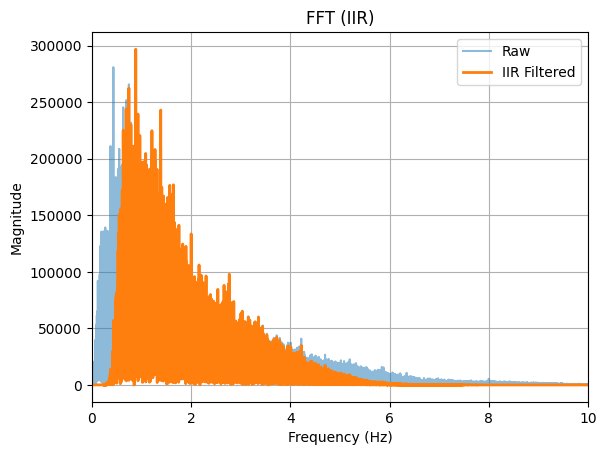

In [ ]:
# =========================
# IMPORT TAMBAHAN
# =========================
from scipy.signal import butter, filtfilt

# =========================
# PARAMETER IIR
# =========================
lowcut = 0.5
highcut = 5
order = 4   # orde filter IIR

nyquist = 0.5 * fs

# =========================
# DESIGN IIR BUTTERWORTH
# =========================
b, a = butter(
    order,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

# =========================
# APPLY FILTER
# =========================
filtered_signal_iir = filtfilt(b, a, signal)

# =========================
# FFT
# =========================
N = len(signal)
freqs = np.fft.fftfreq(N, 1/fs)[:N//2]

fft_raw = np.abs(np.fft.fft(signal)[:N//2])
fft_iir = np.abs(np.fft.fft(filtered_signal_iir)[:N//2])

# =========================
# PLOT TIME DOMAIN
# =========================
plt.figure()
plt.plot(signal, label='Raw', alpha=0.5)
plt.plot(filtered_signal_iir, label='IIR Filtered', linewidth=2)
plt.title("Time Domain (IIR)")
plt.legend()
plt.grid()

# =========================
# PLOT FFT
# =========================
plt.figure()
plt.plot(freqs, fft_raw, label='Raw', alpha=0.5)
plt.plot(freqs, fft_iir, label='IIR Filtered', linewidth=2)

plt.xlim(0, 10)

plt.title("FFT (IIR)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()

plt.show()